# Explore here

In [369]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from typing import Dict, List, Tuple
import joblib
import matplotlib as mpl
import warnings
# modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency

# escalado y encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel


In [370]:


archivo = '/workspaces/antonio.romero.machine-learning-python-template/data/raw/internal-link.csv'
df = pd.read_csv(archivo)

In [371]:
df['name'] = df['name'].str.replace(r'\$', '', regex=True)

In [372]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [373]:
df.shape

(48895, 16)

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [375]:
#Eliminar columnas irrelevantes
cols_to_drop = ["id", "name", "host_id", "host_name"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)



## Análisis de duplicados

In [376]:
df.duplicated().sum()

np.int64(0)

## Análisis de nulos

In [377]:
# Ver el porcetaje de nulos por columna
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df["missing_%"] = (missing_df["missing_count"] / len(df)) * 100

top_missing = missing_df.sort_values(by="missing_%", ascending=False)

display(top_missing.head(20))

,column,missing_count,missing_%
8,last_review,10052,20.558339
9,reviews_per_month,10052,20.558339
0,neighbourhood_group,0,0.000000
1,neighbourhood,0,0.000000
3,longitude,0,0.000000
2,latitude,0,0.000000
4,room_type,0,0.000000
5,price,0,0.000000
7,number_of_reviews,0,0.000000
6,minimum_nights,0,0.000000


In [378]:
# Acciones tras comprobar los nulos

# Relleno los valores nulos con ceros.
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# last_review: convertir a datetime y asignar marcador neutro
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce") # covertir el formato texto en fecha.
df["last_review"] = df["last_review"].fillna(df["last_review"].min())  # Evito sesgo rellenando los valores por la fecha más antigua del dataset para forzar que no lo muestre como fecha reciente.

# Calcular días desde la última reseña
df["days_since_last_review"] = (df["last_review"].max() - df["last_review"]).dt.days

Se detectaron valores nulos en reviews_per_month (21%) y last_review (21%).

reviews_per_month: los valores nulos se reemplazaron por 0, ya que representan alojamientos sin reseñas registradas.

last_review: se convirtió al formato datetime y los valores nulos se imputaron con una fecha simbólica para mantener la consistencia temporal sin introducir sesgo.

days_since_last_review: se recalculó una vez imputados los valores de last_review, para representar correctamente el número de días transcurridos desde la última reseña disponible.

## Detección y tratamiento de Outliers

In [379]:
# Analizo outliers

num_cols = df.select_dtypes(include=["float64", "int64"]).columns

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_summary.append({
        "Variable": col,
        "Outliers": len(outliers),
        "Porcentaje": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values(by="Outliers", ascending=False))

,Variable,Outliers,Porcentaje
8,days_since_last_review,10055,20.56
6,calculated_host_listings_count,7081,14.48
3,minimum_nights,6607,13.51
4,number_of_reviews,6021,12.31
5,reviews_per_month,3312,6.77
2,price,2972,6.08
1,longitude,2833,5.79
0,latitude,425,0.87
7,availability_365,0,0.00


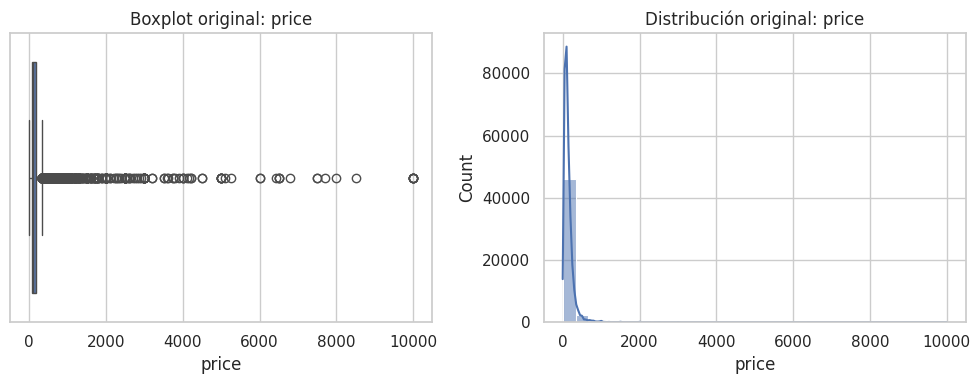

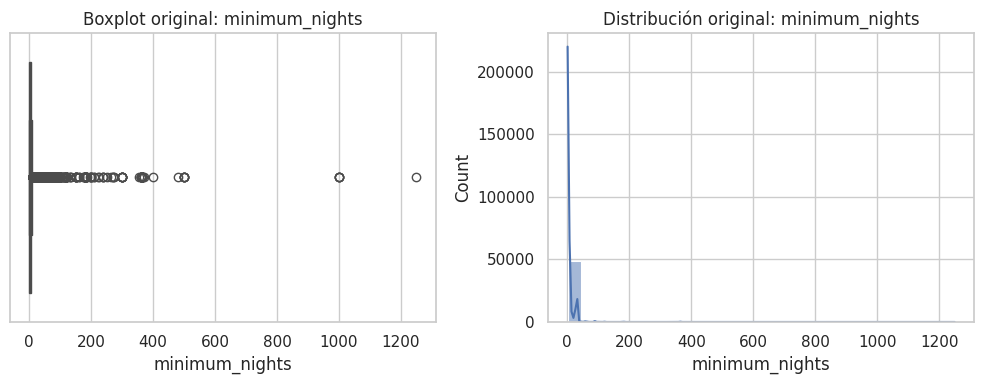

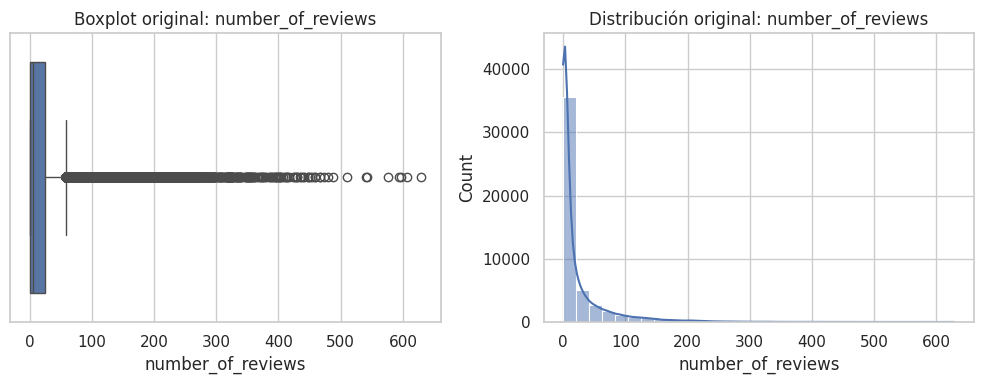

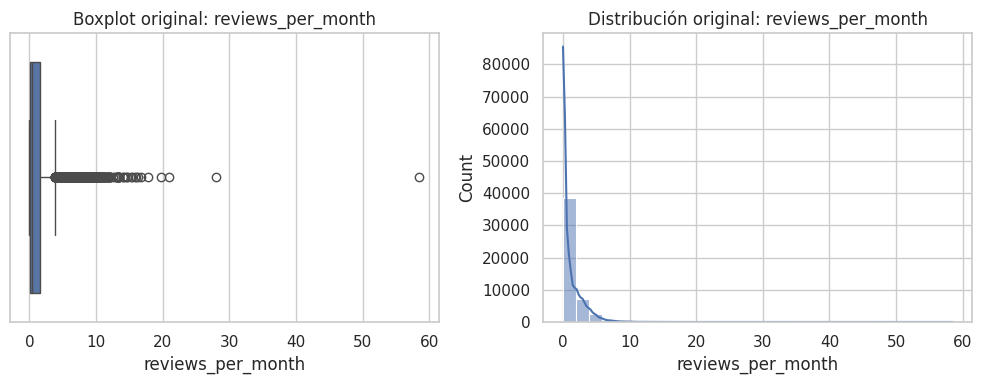

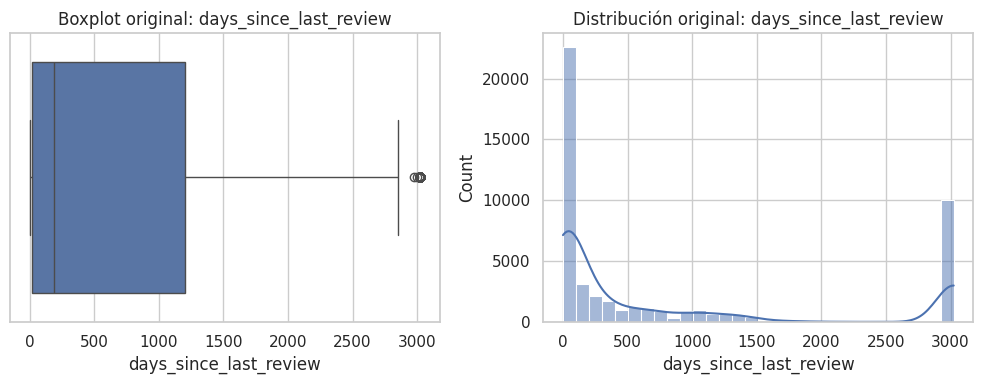

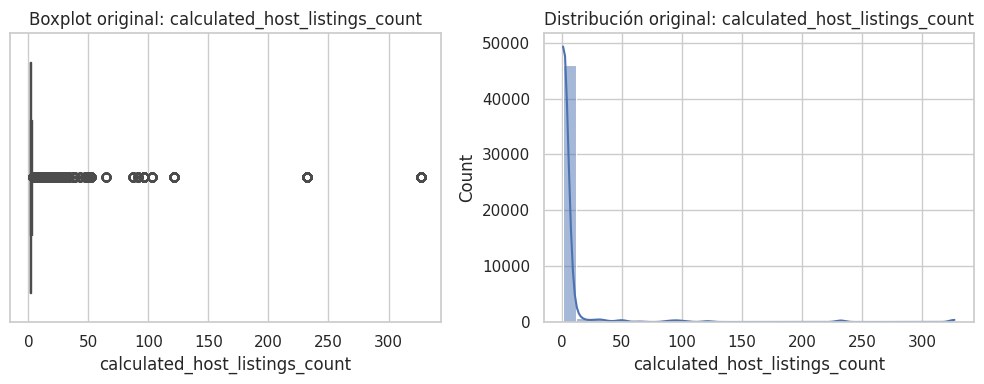

In [380]:
# Según este resultado, longitude y latitude al ser coordenadas, se excluyen. "Neighbourhood", "room_type" y "last_review" no serían variables numéricas reales.
# Tendría sentido windsorizar las siguientes variables

cols_winsorize = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "days_since_last_review",
    "calculated_host_listings_count"
]

for col in cols_winsorize:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot original: {col}")
    
    plt.subplot(1,2,2)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribución original: {col}")
    
    plt.tight_layout()
    plt.show()

In [381]:
# Hacemos windorización
df_wins = df.copy()
for col in cols_winsorize:
    df_wins[col] = winsorize(df[col], limits=[0.01, 0.01])  # recorta 1% en cada extremo

In [382]:
# Comparamos el antes y después:

summary_before = df[cols_winsorize].describe().T
summary_after  = df_wins[cols_winsorize].describe().T
comparison = summary_before[["min","25%","50%","75%","max"]].join(
    summary_after[["min","25%","50%","75%","max"]],
    lsuffix="_before", rsuffix="_after"
)
display(comparison)


,min_before,25%_before,50%_before,75%_before,max_before,min_after,25%_after,50%_after,75%_after,max_after
price,0.0,69.00,106.00,175.00,10000.0,30.0,69.00,106.00,175.00,799.0
minimum_nights,1.0,1.00,3.00,5.00,1250.0,1.0,1.00,3.00,5.00,45.0
number_of_reviews,0.0,1.00,5.00,24.00,629.0,0.0,1.00,5.00,24.00,214.0
reviews_per_month,0.0,0.04,0.37,1.58,58.5,0.0,0.04,0.37,1.58,6.8
days_since_last_review,0.0,19.00,186.00,1201.00,3024.0,1.0,19.00,186.00,1201.00,3024.0
calculated_host_listings_count,1.0,1.00,1.00,2.00,327.0,1.0,1.00,1.00,2.00,232.0


Se identificaron valores extremos principalmente en price, minimum_nights y number_of_reviews. Estos reflejan la heterogeneidad natural del mercado más que errores de registro. Por ello, no se eliminaron, pero se simuló una winsorización para evaluar su impacto estadístico. Las variables categóricas no fueron consideradas en este análisis al no ser apropiadas para detección de outliers mediante IQR.

## Variables categóricas

In [383]:
df.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [384]:
df.neighbourhood.value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [385]:
df.room_type.value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

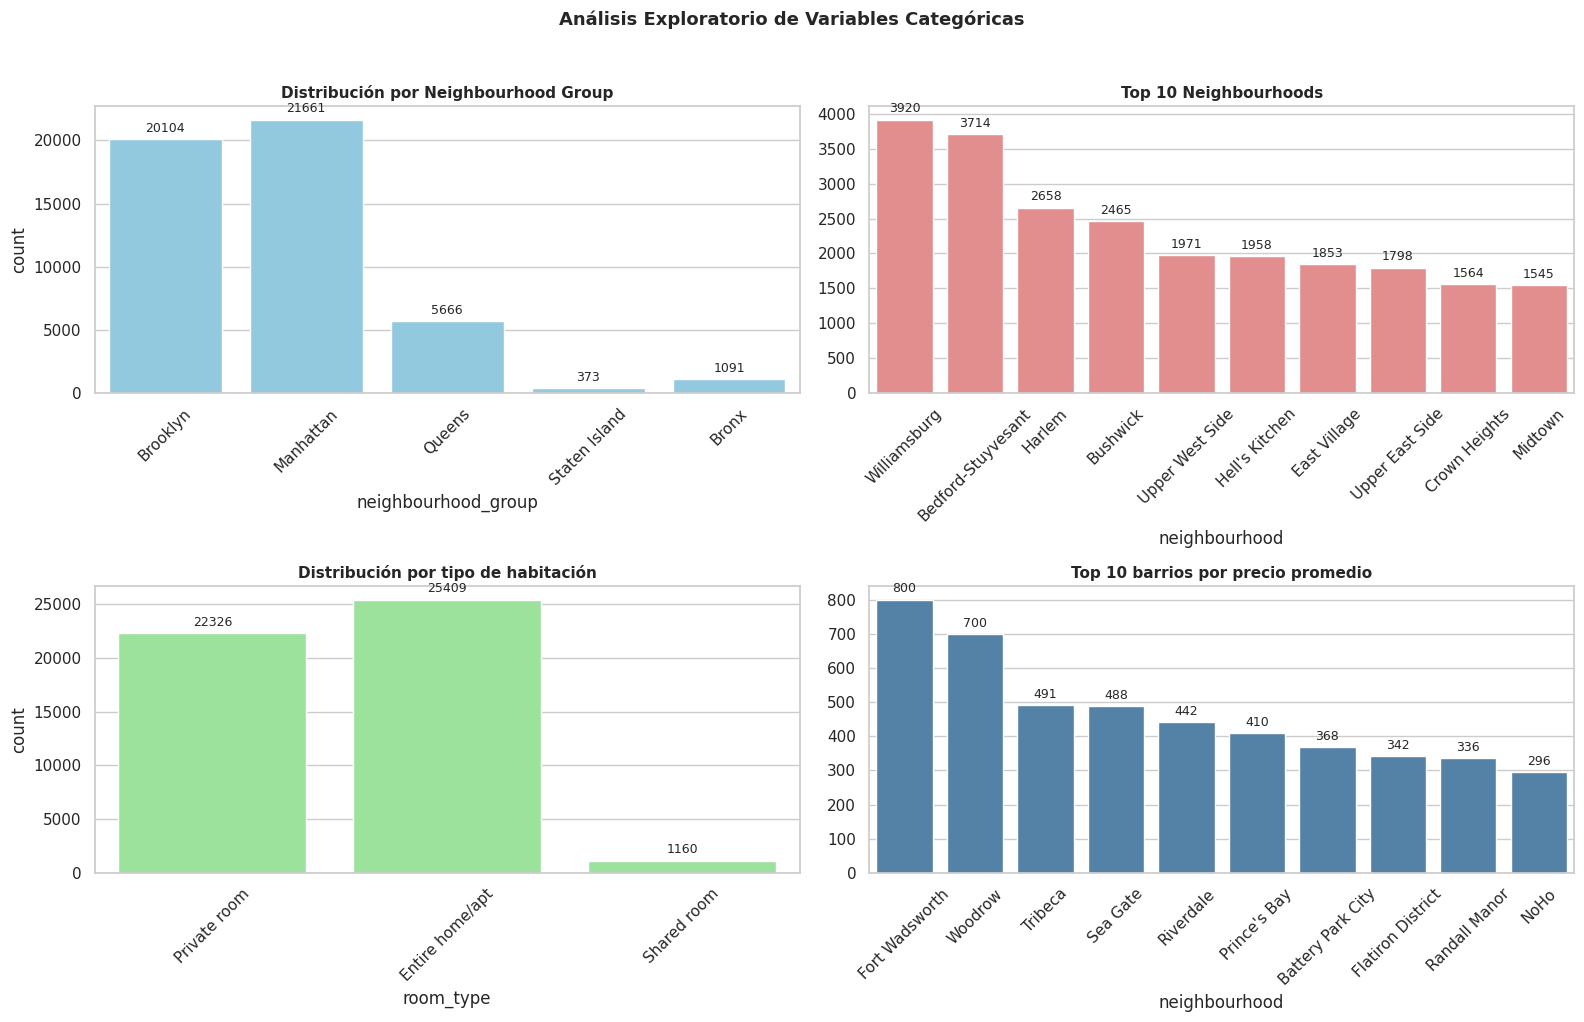

In [386]:
sns.set_theme(style="whitegrid")
mpl.rcParams['text.usetex'] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

fig, axis = plt.subplots(2, 2, figsize=(16, 10))

# Distribución por Neighbourhood Group
ax = sns.countplot(ax=axis[0, 0], data=df, x="neighbourhood_group", color="skyblue")
axis[0, 0].set_title("Distribución por Neighbourhood Group", fontsize=11, fontweight="bold")
axis[0, 0].tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

# Top 10 Neighbourhood
top_neigh = df['neighbourhood'].value_counts().head(10)
ax = sns.barplot(ax=axis[0, 1], x=top_neigh.index, y=top_neigh.values, color="lightcoral")
axis[0, 1].set_title("Top 10 Neighbourhoods", fontsize=11, fontweight="bold")
axis[0, 1].tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

# Distribución por tipo de habitación
ax = sns.countplot(ax=axis[1, 0], data=df, x="room_type", color="lightgreen")
axis[1, 0].set_title("Distribución por tipo de habitación", fontsize=11, fontweight="bold")
axis[1, 0].tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

# Top 10 barrios por precio promedio
top_price = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
ax = sns.barplot(ax=axis[1, 1], x=top_price.index, y=top_price.values, color="steelblue")
axis[1, 1].set_title("Top 10 barrios por precio promedio", fontsize=11, fontweight="bold")
axis[1, 1].tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=3)

# Ajustes finales
plt.suptitle("Análisis Exploratorio de Variables Categóricas", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



### Análisis de las categorías: 
Barrios: La mayor parte de alojamientos se concentran en los grupos de vecindarios de Manhattan y Brooklyn (85% del total aprox.). Los barrios de Williamsburg, Bedford y Harlem concentran el mayor número de alojamientos

Tipos de habitación: el mercado parece orientado a viviendas completas, seguido por alquiler de habitaciones privadas. Las habitaciones compartidas no sobrepasan el 3%

Precios: el precio medio más elevado se encuentra principalmente en Manhattan. hay una dispersión de precios notable, multiplicando exponencialmente el valor medio general



Las variables price, minimum_nights y number_of_reviews presentan colas largas derechas, lo que indica valores atípicos asociados a propiedades de lujo (o huéspedes con mucha rotación). 

## Variables numéricas

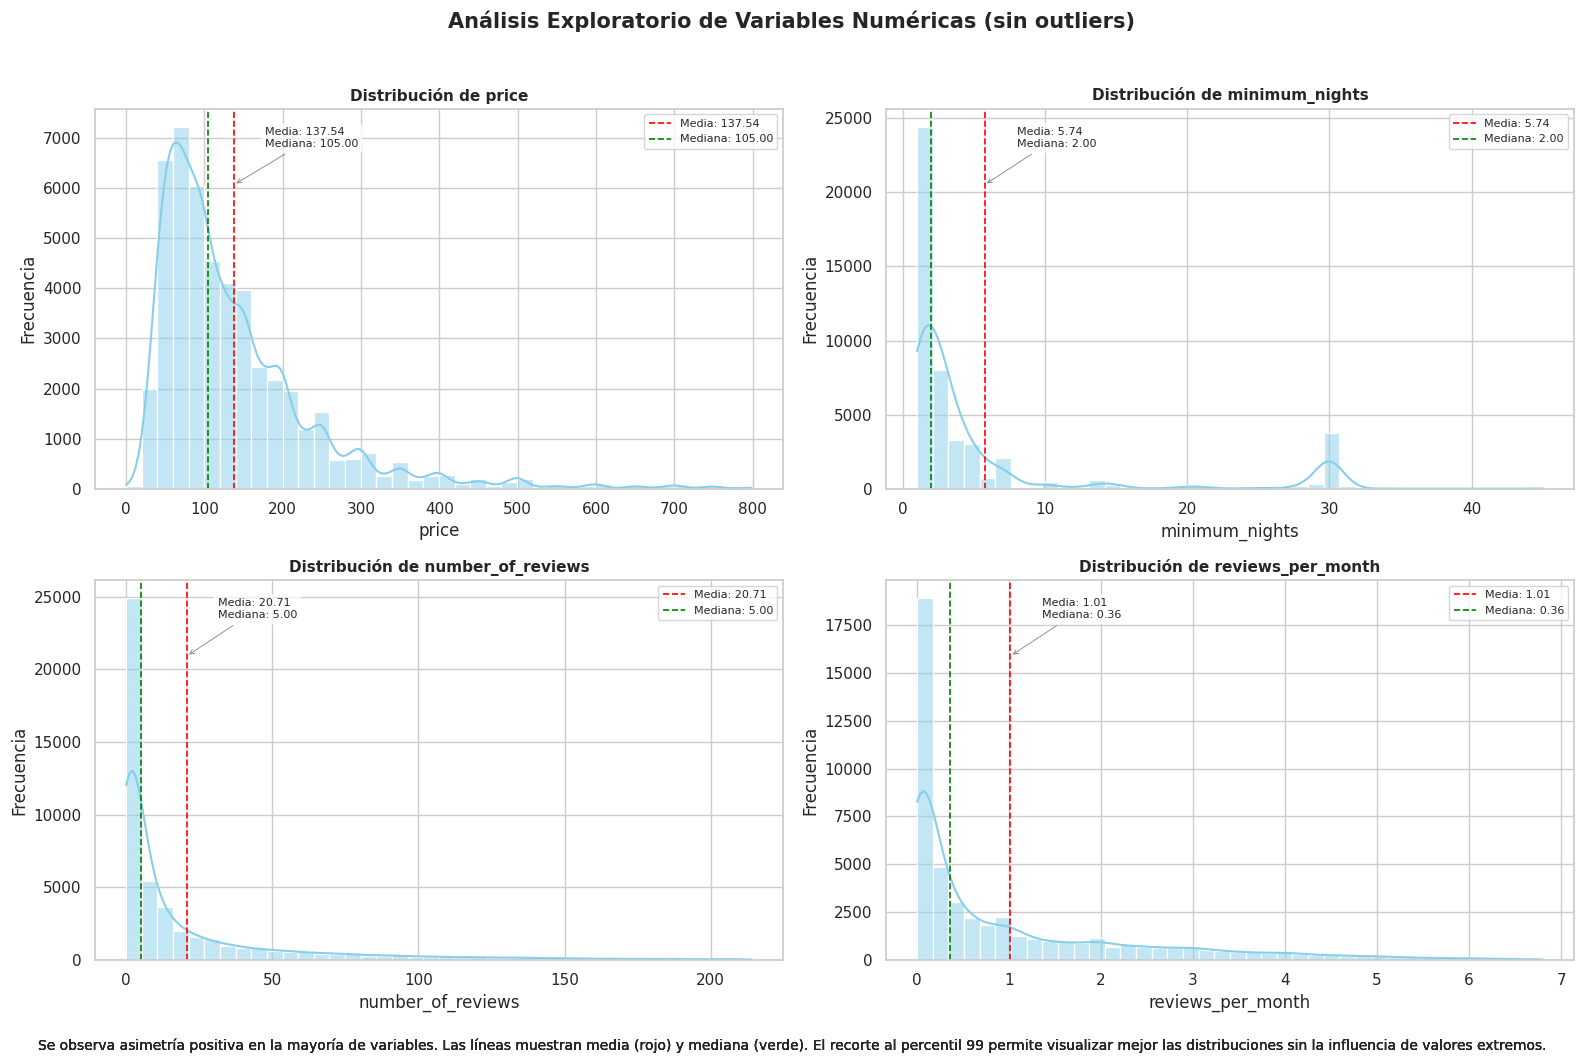

In [387]:
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

fig, axis = plt.subplots(2, 2, figsize=(16, 10))
axis = axis.flatten()

plots = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month"]

for i, col in enumerate(plots):
    ax = axis[i]

    # Limitar el rango al percentil 99 para representar mejor las colas
    upper_limit = df[col].quantile(0.99)

    sns.histplot(data=df[df[col] <= upper_limit], x=col, bins=40, kde=True, color="skyblue", ax=ax)
    ax.set_title(f"Distribución de {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

      # Estadísticos sobre el subconjunto limitado
    mean_val = df[df[col] <= upper_limit][col].mean()
    median_val = df[df[col] <= upper_limit][col].median()

    # Líneas de referencia
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.2, label=f"Media: {mean_val:,.2f}")
    ax.axvline(median_val, color="green", linestyle="--", linewidth=1.2, label=f"Mediana: {median_val:,.2f}")

    # Anotaciones
    ax.annotate(f"Media: {mean_val:,.2f}\nMediana: {median_val:,.2f}",
                xy=(mean_val, ax.get_ylim()[1]*0.8),
                xytext=(mean_val + (upper_limit*0.05), ax.get_ylim()[1]*0.9),
                fontsize=8,
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'),
                arrowprops=dict(arrowstyle="->", lw=0.6, color="gray"))

    ax.legend(fontsize=8)

    # Comentario bajo el gráfico:
    plt.figtext(0.5, -0.02,
    "Se observa asimetría positiva en la mayoría de variables. Las líneas muestran media (rojo) y mediana (verde). "
    "El recorte al percentil 99 permite visualizar mejor las distribuciones sin la influencia de valores extremos.",
    ha='center', fontsize=10)

plt.suptitle("Análisis Exploratorio de Variables Numéricas (sin outliers)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

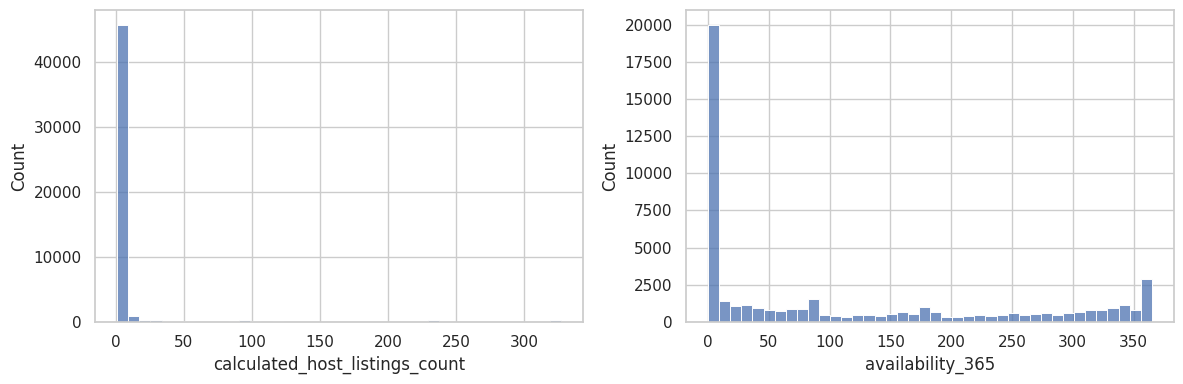

In [388]:
# Variables numéricas no analizadas en primer borrador del ejercicio.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="calculated_host_listings_count", bins=40, ax=axes[0])
sns.histplot(data=df, x="availability_365", bins=40, ax=axes[1])

plt.tight_layout()
plt.show()


### Análisis de las variables numéricas:

Price: la distribución presenta asimetría clara hacia la izquierda. La mayor parte de precios se encuentran por debajo de 250€, aunque algunos apartamentos superan los 1000€, siendo estos alojamientos con ubicaciones excepcionales o de tipo premium.

Minimum nights: la mayor parte exigen estancias mínimas cortas de entre 2 y 5 noches. Los outliers con más de 100 noches pueden considerarse alquileres de largo plazo, pero son marginales a la tendencia general.

Reviews: pese a que existen propiedades con más de 3 reseñas al mes, la muestra refleja por debajo de una reseña al mes. La mayor parte de reseñas se concentran en valores bajos, es decir unas cuantas propiedades son populares, pero la mayor parte mantiene valores bajos.

Latitud y Longitude: no analizadas al ser variables geográficas

Calculated host listing count: la mayor parte de anfitriones gestionan una propiedad únicamente. Aquellos denominados superhosts parecen regentar varios, algunos con más de 10 apartamentos.

Availability:  La disponibilidad se concentra en valores intermedios (50-250 días).

### Correlación entre variables categóricas.


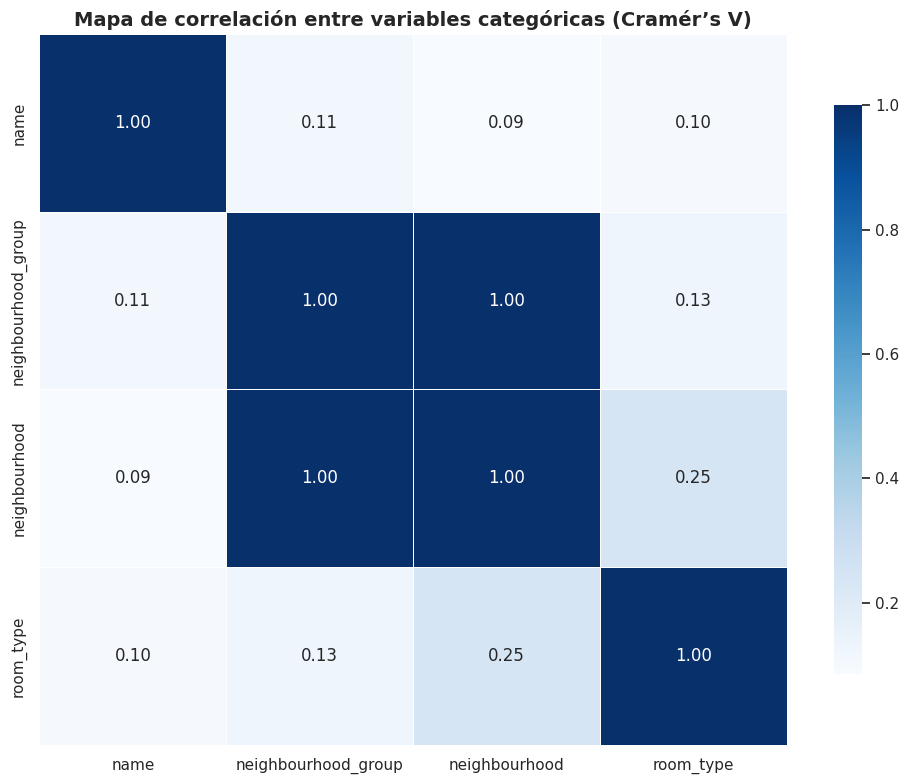

In [ ]:
# Seleccionar solo las columnas categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Función para calcular Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Crear matriz vacía
cramers_results = pd.DataFrame(index=cat_cols, columns=cat_cols)

# Calcular Cramér’s V para cada par de variables categóricas
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convertir a tipo float
cramers_results = cramers_results.astype(float)

# Visualizar con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_results,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de correlación entre variables categóricas (Cramér’s V)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Valores cercanos a 0 = sin relación.

Valores entre 0.3 y 0.7 = relación moderada.

Valores > 0.7 = fuerte relación entre categorías.

No parece existir una relación directa entre los tipos de habitación y el vecindario.

### Correlación entre variables numéricas.


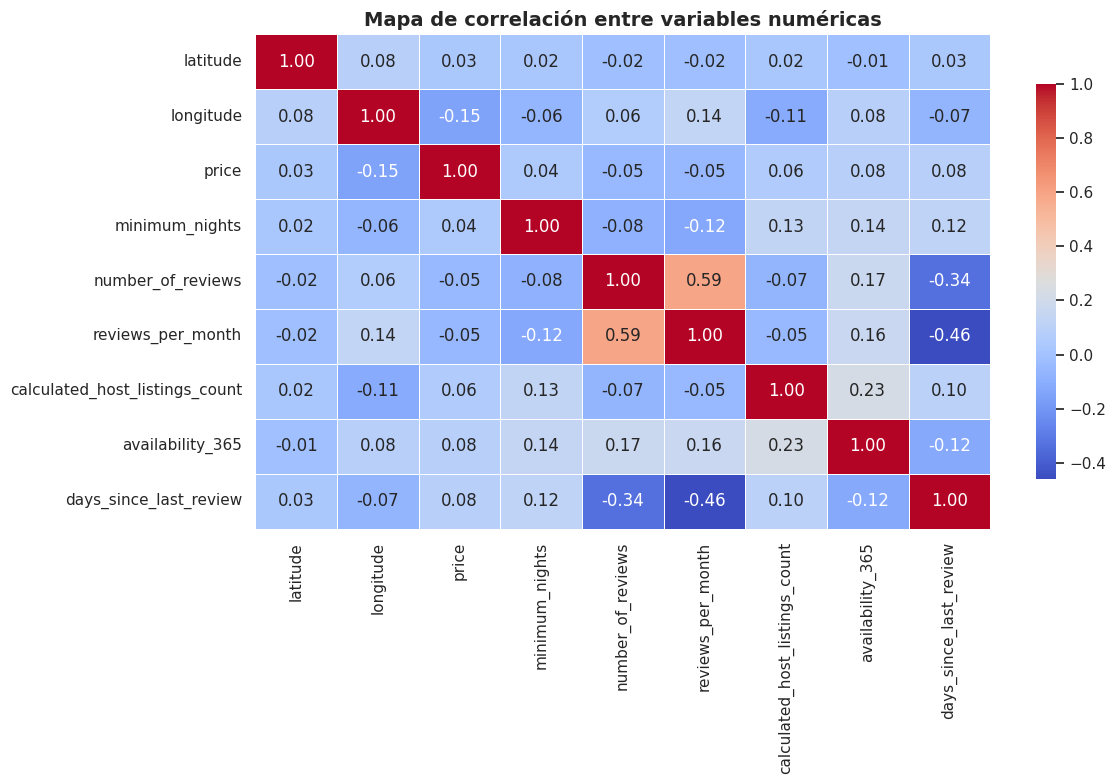

In [389]:
# Seleccionar solo las columnas numéricas
num_cols = df.select_dtypes(include=["number"])

# Calcular la matriz de correlación
corr_matrix = num_cols.corr()

# Configurar el tamaño del gráfico y crear el mapa de calor
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,        # muestra los valores de correlación
    fmt=".2f",         # formato de los decimales
    linewidths=0.5,    # separación entre celdas
    cbar_kws={"shrink": 0.8},  # ajustar barra de color
)

plt.title("Mapa de correlación entre variables numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Number_of_reviews y reviews_per_month muestran una correlación positiva moderada (≈ 0.59), coherente con la relación esperada entre volumen de reseñas y frecuencia mensual.

Reviews_per_month y days_since_last_review presentan una correlación negativa moderada (-0.46): cuanto más tiempo ha pasado desde la última reseña, menor suele ser la frecuencia mensual de comentarios.

Number_of_reviews y days_since_last_review también se correlacionan negativamente (-0.34), reforzando la misma tendencia.

Las variables latitude, longitude, price, availability_365 y calculated_host_listings_count muestran correlaciones muy débiles (<0.2) con el resto, indicando independencia geográfica y económica respecto a las métricas de reseñas o actividad.

## Correlaciones entre variables numéricas y categóricas

,Categórica,Numérica,Correlación_eta2
9,neighbourhood,latitude,0.994864
10,neighbourhood,longitude,0.987615
0,neighbourhood_group,latitude,0.777353
1,neighbourhood_group,longitude,0.761679
15,neighbourhood,calculated_host_listings_count,0.476918
16,neighbourhood,availability_365,0.270990
11,neighbourhood,price,0.259402
14,neighbourhood,reviews_per_month,0.257287
20,room_type,price,0.256152
19,room_type,longitude,0.192148


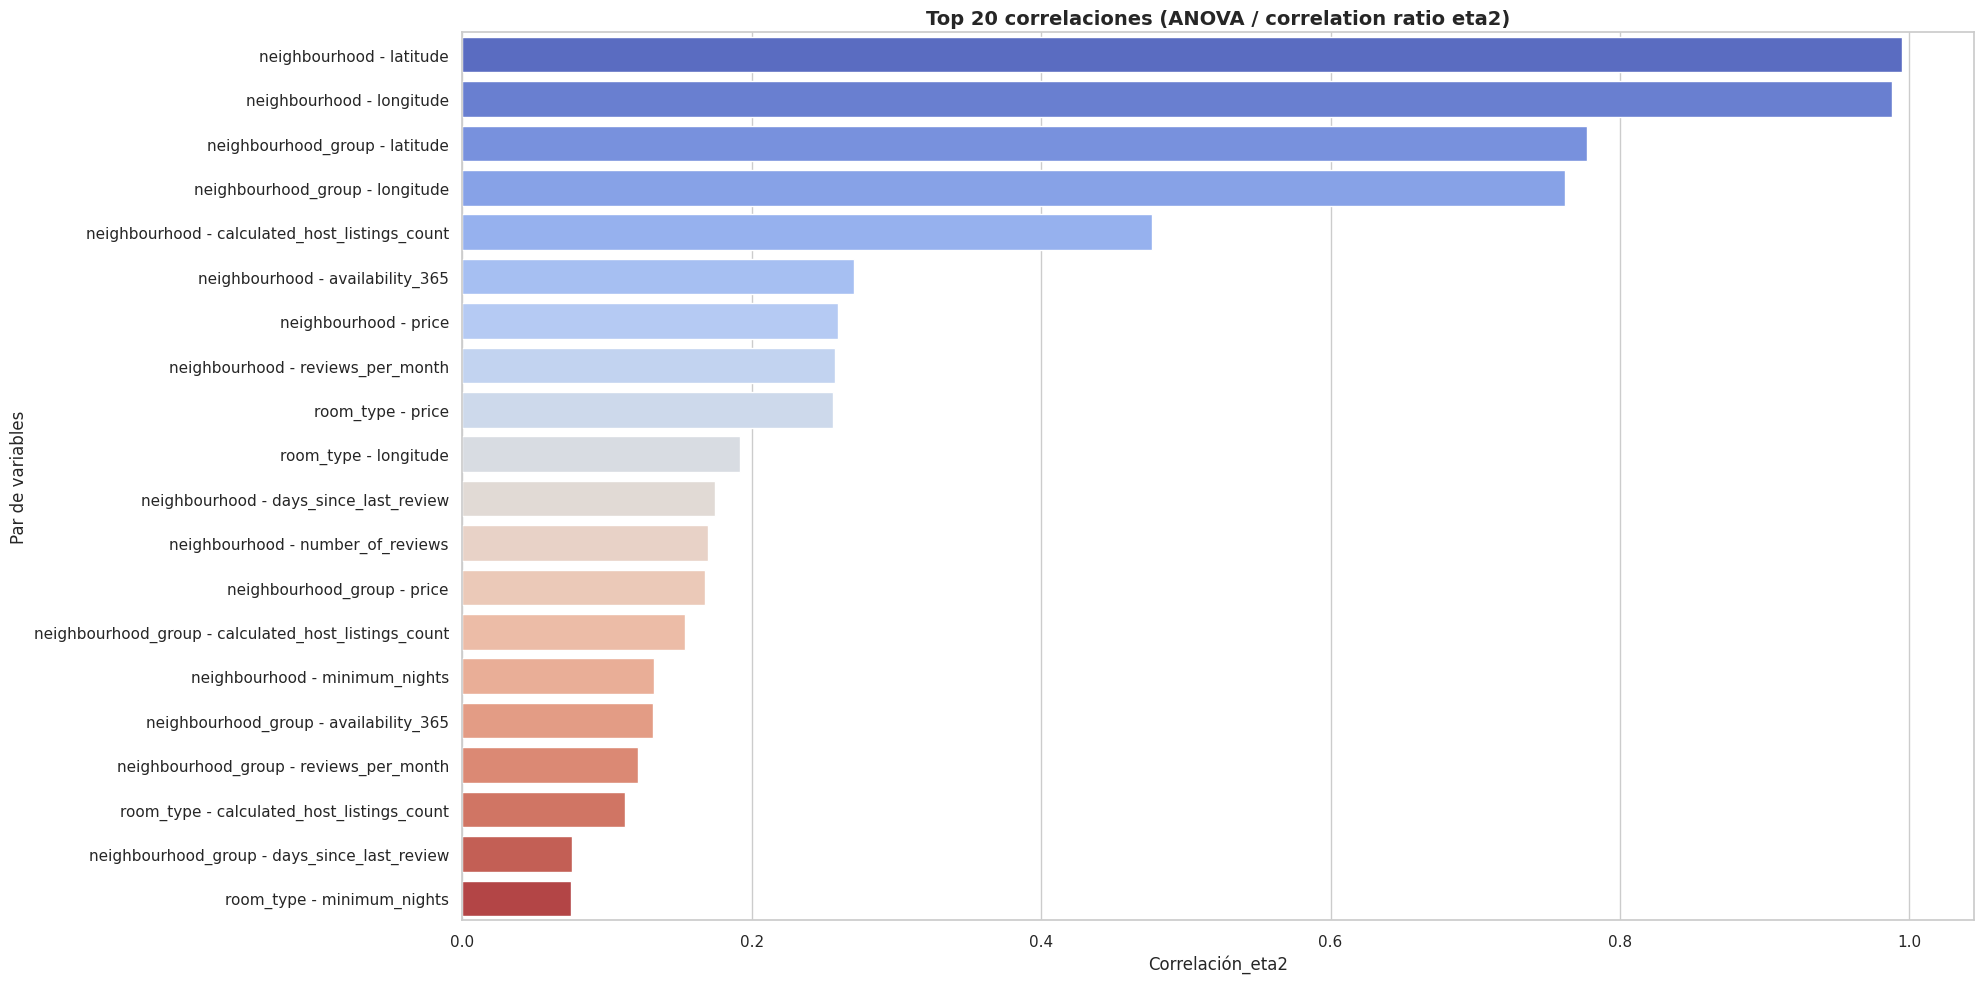

In [390]:
# Función: correlation ratio eta2
def correlation_ratio(categories, values):
    categories = pd.Categorical(categories)
    cat_means = values.groupby(categories, observed=True).mean()
    n_per_cat = values.groupby(categories, observed=True).count()
    grand_mean = values.mean()
    numerator = sum(n_per_cat * (cat_means - grand_mean) ** 2)
    denominator = sum((values - grand_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# Seleccionar variables
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Calcular la correlación eta2 entre cada par categórico-numérico (ANOVA)
anova_results = []
for cat in cat_cols:
    for num in num_cols:
        eta = correlation_ratio(df[cat], df[num])
        anova_results.append({"Categórica": cat, "Numérica": num, "Correlación_eta2": eta})

anova_df = pd.DataFrame(anova_results).sort_values(by="Correlación_eta2", ascending=False)

# Mostrar top 10
display(anova_df.head(10))

# Graficar top 20 correlaciones
plt.figure(figsize=(20, 10))
sns.barplot(
    data=anova_df.head(20),
    x="Correlación_eta2",
    y=anova_df.head(20).apply(lambda row: f"{row['Categórica']} - {row['Numérica']}", axis=1),
    hue=anova_df.head(20).apply(lambda row: f"{row['Categórica']} - {row['Numérica']}", axis=1),
    palette="coolwarm"
)
plt.title("Top 20 correlaciones (ANOVA / correlation ratio eta2)", fontsize=14, fontweight="bold")
plt.xlabel("Correlación_eta2")
plt.ylabel("Par de variables")
plt.tight_layout()
plt.show()


Las dimensiones geográficas y de tipo de alojamiento son las que más explican la varianza en las métricas cuantitativas 
(precio, disponibilidad y volumen de reseñas). Esto valida que la ubicación y el tipo de propiedad son los principales determinantes del comportamiento de los listados en el mercado. 



## Escalado de variables numéricas

In [391]:
print(df.select_dtypes(include=["float64", "int64"]).columns)

Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'days_since_last_review'],
      dtype='object')


In [392]:
# Aseguramos que todas las variables contribuyan por igual. 

# Excluyo "latitude" y "longitud"

exclude_cols = ["latitude", "longitude"]
num_cols = [col for col in num_cols if col not in exclude_cols] 

# Me aseguro de que "price" esté limpio y convertido a número

df["price"] = df["price"].replace('[\$,€]', '', regex=True)
df["price"] = pd.to_numeric(df["price"], errors='coerce')

# Uso StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])  # num_cols ya definido

# Convertir de nuevo a DataFrame si lo necesitas
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols, index=df.index)


## Codificación de categorías nominales

In [393]:
# Defino categorias para codificar

nominal_cols = ["neighbourhood_group", "room_type"]


In [394]:
# Instanciamos el encoder
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

# Ajustamos en train y transformamos ambos conjuntos
X_train_ohe = ohe.fit_transform(X_train[nominal_cols])
X_test_ohe = ohe.transform(X_test[nominal_cols])

# Convertimos los resultados en DataFrames con nombres de columnas
ohe_cols = ohe.get_feature_names_out(nominal_cols)
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test.index)

# Concatenamos las columnas codificadas al resto de variables numéricas
X_train_final = pd.concat([X_train.drop(columns=nominal_cols), X_train_ohe], axis=1)
X_test_final = pd.concat([X_test.drop(columns=nominal_cols), X_test_ohe], axis=1)

X_train_final.head()

,neighbourhood,latitude,longitude,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
32645,Williamsburg,40.71577,-73.95530,3,11,2019-05-16,0.87,1,1,53,1.0,0.0,0.0,0.0,0.0,0.0
23615,Washington Heights,40.84917,-73.94048,2,2,2018-06-25,0.16,1,0,378,0.0,1.0,0.0,0.0,1.0,0.0
31183,Bedford-Stuyvesant,40.68993,-73.95947,2,0,2011-03-28,0.00,2,0,3024,1.0,0.0,0.0,0.0,1.0,0.0
29260,Bedford-Stuyvesant,40.68427,-73.93118,3,87,2019-07-05,4.91,1,267,3,1.0,0.0,0.0,0.0,0.0,0.0
7275,Woodside,40.74705,-73.89564,5,13,2018-12-18,0.25,1,0,202,0.0,0.0,1.0,0.0,1.0,0.0
